In [2]:
import numpy as np
import pandas as pd
import torch

import sys
sys.path.append('../')
from utilities import binning_equal_q

In [5]:
def infer_fields(data, counts):
    
    fields = np.zeros([7,20])
    for pos in range(7):
        for color in range(20):
            fields[pos,color] = (counts*((data[:,pos] == color).astype('int'))).sum() 

    print(counts.sum(), fields.sum(1))

    fields = fields[:,:] / fields[:,0][:,np.newaxis]
    return torch.tensor(np.log(fields))

def sorted_log10p_vector_from_fields(fields):
    
    lengths = [torch.arange(20, dtype=torch.int8) for i in range(7)]
    all_seq = torch.cartesian_prod(*lengths)
    
    all_seq = all_seq.long()
    
    # generate p_vector
    p_vector = torch.zeros(20**7,dtype=torch.float32)

    for i in range(7):
        p_vector += fields[i,all_seq[:,i]]
        print(i)
    
    p_vector = torch.exp(p_vector)
    
    Z = torch.exp(fields).sum(1).prod()
    
    p_vector /= Z
    print(p_vector.sum())
    
    return torch.log(p_vector).sort()[0] / np.log(10)

def log10q_vector_func(data, fields):
    
    # generate q_vector
    q_vector = torch.zeros(len(data))

    for i in range(7):
        q_vector += fields[i,data[:,i]]
        print(i)

    q_vector = torch.exp(q_vector)

    Z = torch.exp(fields).sum(1).prod()

    q_vector /= Z

    print(q_vector.sum())
    return np.log10(q_vector.numpy())

In [19]:
data = pd.read_csv('../data/Byrne.csv',index_col=0).query('T0 > 0')
data = data.sort_values('T0', ascending=False)
data = data.iloc[1:,:]

counts = data['T0'].to_numpy()
data = data.iloc[:,:7].to_numpy()

In [20]:
fields = infer_fields(data, counts)

12195473 [12195473. 12195473. 12195473. 12195473. 12195473. 12195473. 12195473.]


In [48]:
fields_numpy = fields.numpy()
pseq = ((fields_numpy[0,16]+fields_numpy[1,15]+fields_numpy[2,8]+fields_numpy[3,0]+fields_numpy[4,16]+fields_numpy[5,7]+fields_numpy[6,0])/np.exp(fields_numpy).sum(1).prod())
pseq

-8.062981086193757e-10

In [42]:
fields_numpy[0,1]

-0.17248431948420634

In [5]:
sorted_log10p_vector = sorted_log10p_vector_from_fields(fields)

0
1
2
3
4
5
6
tensor(1.)


In [6]:
log10q_vector = log10q_vector_func(data, fields)
argsort = np.argsort(log10q_vector)
sorted_log10q_vector = log10q_vector[argsort][::-1]
counts = counts[argsort][::-1]

0
1
2
3
4
5
6
tensor(0.0130)


In [7]:
bins=80
df_bins = binning_equal_q(sorted_log10p_vector, sorted_log10q_vector, counts, bins=bins, writefolder='results_ByrneT0_IM', step=1)
df_bins.to_csv('df_bins_Byrne_IM_%dbins.csv'%bins)

0
tensor(1279999999) tensor(1279655622)
elements in the bin: 344377
nonzeros: 38393
1
tensor(1279655622) tensor(1279137703)
elements in the bin: 517919
nonzeros: 38393
2
tensor(1279137703) tensor(1278496952)
elements in the bin: 640751
nonzeros: 38393
3
tensor(1278496952) tensor(1277748115)
elements in the bin: 748837
nonzeros: 38393
4
tensor(1277748115) tensor(1276900422)
elements in the bin: 847693
nonzeros: 38393
5
tensor(1276900422) tensor(1275940685)
elements in the bin: 959737
nonzeros: 38393
6
tensor(1275940685) tensor(1274897010)
elements in the bin: 1043675
nonzeros: 38393
7
tensor(1274897010) tensor(1273747624)
elements in the bin: 1149386
nonzeros: 38393
8
tensor(1273747624) tensor(1272505426)
elements in the bin: 1242198
nonzeros: 38393
9
tensor(1272505426) tensor(1271170602)
elements in the bin: 1334824
nonzeros: 38393
10
tensor(1271170602) tensor(1269745267)
elements in the bin: 1425335
nonzeros: 38393
11
tensor(1269745267) tensor(1268216095)
elements in the bin: 1529172


## Write down F

In [8]:
df_bins = pd.read_csv('df_bins_Byrne_IM_80bins.csv',index_col=0)
F_vec = np.zeros(2)
F_vec[0] = ((df_bins['var_count'] - df_bins['var_lambda']) / df_bins['mean_count']).mean()
F_vec[1] = ((df_bins['var_count'] - df_bins['var_lambda']) / df_bins['mean_count']).std()
np.savetxt('F_Byrne.csv',F_vec,delimiter=',')
F_vec

array([8.92247337, 0.44065842])

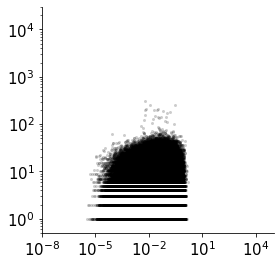

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3.8),facecolor='white')
ax = plt.subplot(111)

x = (10**sorted_log10q_vector)*counts.sum()
y = counts
plt.scatter(x,y, marker='.', color='black', alpha=0.2, linewidth=0)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5e-1,3e4)
plt.xlim(1e-8,1e5)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../fig1_paper/Byrne_empirical_vs_predicted.png', dpi=1200)